In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from tqdm import tqdm 
from scipy.stats import norm

## Дизайн:
1. Генеральная совокупность: $\mu=50,\; \sigma=10,\; n=100\;000$;
2. Параметры: $\alpha=0.05$ и $\beta=0.20$;
3. Целевая метрика: среднее;
4. $H_{0}: A_{avg} = B_{avg}$ и $H_{1}: A_{avg} \neq B_{avg}$
4. Серия АА-тестов: 10000 тестов по 1000 наблюдений в А/В и в каждом тесте: 
    1. Считаем целевую метрику;
    2. Проводим Т-тест;
    3. Проводим тест правдоподобия – вероятность популяции при полученной статистике в группе А, вероятность поплуяции при полученной статистике в группе В;     

In [109]:
params = {
    'mu': 50,
    'sigma': 10,
    'population_n': 100_000,
    'sample_n': 10_000,
    'alpha': 0.05,
    'beta': 0.20,
    'experiments': 10_000
}

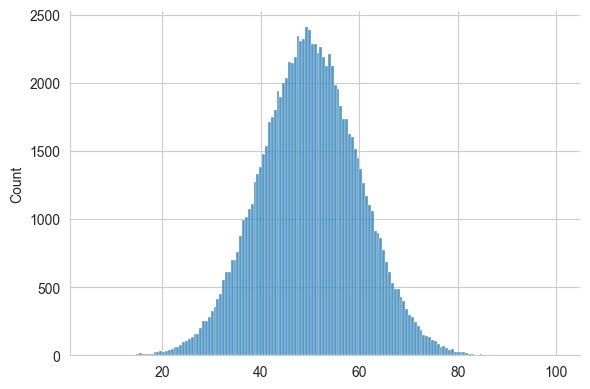

In [66]:
rng = np.random.default_rng(seed=42)
population = rng.normal(size=params['population_n'], loc=params['mu'], scale=params['sigma'])
sns.displot(population, aspect=1.5, height=4);

In [116]:
def run_simulation(sample_n):
    """Симуляция одного Т-теста"""
    
    choice = lambda x: np.random.choice(x, size=sample_n, replace=True)
    sample_a, sample_b = choice(population), choice(population)
    
    sample_a_avg, sample_b_avg = np.mean(sample_a), np.mean(sample_b)
    sample_a_std, sample_b_std = np.std(sample_a, ddof=1), np.std(sample_b, ddof=1)
    
    t_stat, p_value = stats.ttest_ind(sample_a, sample_b)
    
    return sample_a_avg, sample_b_avg, t_stat, p_value

In [117]:
results = [
    run_simulation(sample_n=params['sample_n']) 
    for _ in tqdm(range(params['experiments']), desc="Running simulations", unit="sim")
]

Running simulations: 100%|██████████| 10000/10000 [00:06<00:00, 1456.23sim/s]


In [119]:
df = pd.DataFrame(
    results, 
    columns=['sample_a_avg', 'sample_b_avg', 't_stat', 'p_value']
)

In [120]:
df

,sample_a_avg,sample_b_avg,t_stat,p_value
0,49.905615,50.022863,-0.823215,0.410396
1,49.821111,49.841183,-0.141835,0.887212
2,49.833082,49.899678,-0.468866,0.639171
3,49.841499,49.971874,-0.915326,0.360031
4,50.097395,49.987720,0.769321,0.441712
...,...,...,...,...
9995,49.996182,50.032214,-0.256528,0.797545
9996,50.084927,49.894205,1.345236,0.178564
9997,50.063798,49.998600,0.459935,0.645568
9998,49.900915,49.931673,-0.216236,0.828806


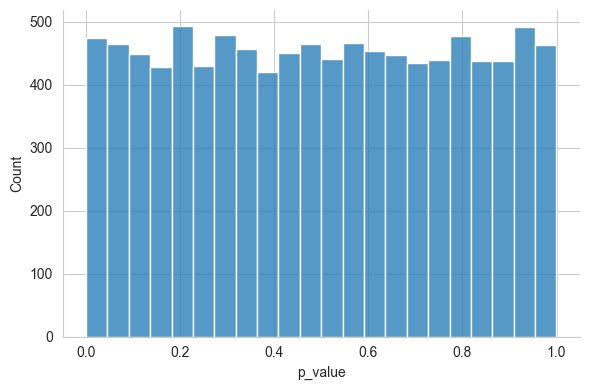

In [126]:
sns.displot(df['p_value'], aspect=1.5, height=4);

In [125]:
# Проверим равномерность распределения ч помощью теста Колмогорова-Смирнова.
p_value = stats.kstest(df['p_value'], 'uniform')[1]
if p_value < 0.05:
    print(f'H0 reject, p_value: {p_value}')
else:
    print(f'H0 not reject. p_value: {p_value}')

H0 not reject. p_value: 0.8960959043598717
